### Data Preparation Workflow for Financial Metrics and Regime Classification

In [9]:
import pandas as pd
import numpy as np

# Load datasets
eps = pd.read_csv(r"D:/LSE Career Accelerator/Employer project/Adrian's financial metrics data/av_eps_quarterly.csv")
margins = pd.read_csv(r"D:/LSE Career Accelerator/Employer project/Adrian's financial metrics data/av_income_quarterly_margins.csv")

In [10]:
# Clean and standardise dates
eps["fiscalDateEnding"] = pd.to_datetime(eps["fiscalDateEnding"])
margins["fiscalDateEnding"] = pd.to_datetime(margins["fiscalDateEnding"])

In [11]:
# Clean numeric fields
numeric_cols = ["reportedEPS", "estimatedEPS", "surprise", "surprisePercentage"]
for col in numeric_cols:
    eps[col] = pd.to_numeric(eps[col], errors="coerce")

margin_numeric_cols = [
    "totalRevenue", "grossProfit", "operatingIncome", "netIncome",
    "grossMargin", "operatingMargin", "netMargin"
]
for col in margin_numeric_cols:
    margins[col] = pd.to_numeric(margins[col], errors="coerce")

In [12]:
# Merge datasets
df = pd.merge(
    eps,
    margins,
    on=["symbol", "fiscalDateEnding"],
    how="inner"   # inner join ensures only matching quarters
)

In [13]:
# Create derived variables

# EPS surprise direction
df["surpriseDirection"] = np.where(df["surprise"] > 0, "positive",
                           np.where(df["surprise"] < 0, "negative", "zero"))

# Surprise magnitude buckets
def bucket_surprise(pct):
    if pd.isna(pct):
        return "missing"
    if abs(pct) < 3:
        return "small"
    elif abs(pct) < 10:
        return "medium"
    else:
        return "large"

df["surpriseBucket"] = df["surprisePercentage"].apply(bucket_surprise)

# Sort for lag calculations
df = df.sort_values(["symbol", "fiscalDateEnding"])

# Margin changes (QoQ)
df["grossMargin_change"] = df.groupby("symbol")["grossMargin"].diff()
df["operatingMargin_change"] = df.groupby("symbol")["operatingMargin"].diff()
df["netMargin_change"] = df.groupby("symbol")["netMargin"].diff()

# Revenue YoY growth 
df["revenue_yoy_growth"] = df.groupby("symbol")["totalRevenue"].pct_change(4)

In [14]:
# Final tidy-up
df = df.reset_index(drop=True)

print(df.head())
print(df.info())

  fiscalDateEnding reportedDate  reportedEPS  estimatedEPS  surprise  \
0       2005-09-30   2005-10-11         0.01          0.01       0.0   
1       2005-12-31   2006-01-18         0.02          0.02       0.0   
2       2006-03-31   2006-04-19         0.02          0.02       0.0   
3       2006-06-30   2006-07-19         0.02          0.02       0.0   
4       2006-09-30   2006-10-18         0.02          0.02       0.0   

   surprisePercentage   reportTime symbol  totalRevenue  grossProfit  ...  \
0                 0.0  post-market   AAPL    3678000000   1035000000  ...   
1                 0.0  post-market   AAPL    5749000000   1564000000  ...   
2                 0.0  post-market   AAPL    4359000000   1297000000  ...   
3                 0.0  post-market   AAPL    4370000000   1325000000  ...   
4                 0.0  post-market   AAPL    4370000000   1412000000  ...   

   netIncome  grossMargin  operatingMargin  netMargin  surpriseDirection  \
0  430000000     0.281403   

In [56]:
# EPS surprise regime
import pandas as pd
import numpy as np

def classify_surprise(pct):
    if pd.isna(pct):
        return "missing"
    if pct > 10:
        return "large_positive"
    elif pct > 3:
        return "moderate_positive"
    elif pct >= -3:
        return "small"
    elif pct >= -10:
        return "moderate_negative"
    else:
        return "large_negative"
 
df["eps_surprise_regime"] = df["surprisePercentage"].apply(classify_surprise)

df[[
    "symbol",
    "fiscalDateEnding",
    "eps_surprise_regime",
]].head()

,symbol,fiscalDateEnding,eps_surprise_regime
0,AAPL,2005-09-30,small
1,AAPL,2005-12-31,small
2,AAPL,2006-03-31,small
3,AAPL,2006-06-30,small
4,AAPL,2006-09-30,small


Very large positive surprises are defined as anything above 10%, capturing quarters where earnings dramatically outperform forecasts. Moderate positive surprises fall between 3% and 10%, while values between –3% and +3% are treated as “small,” reflecting quarters where results are essentially in line with expectations. Moderate negative surprises range from –3% to –10%, and anything below –10% is considered a large negative surprise. 

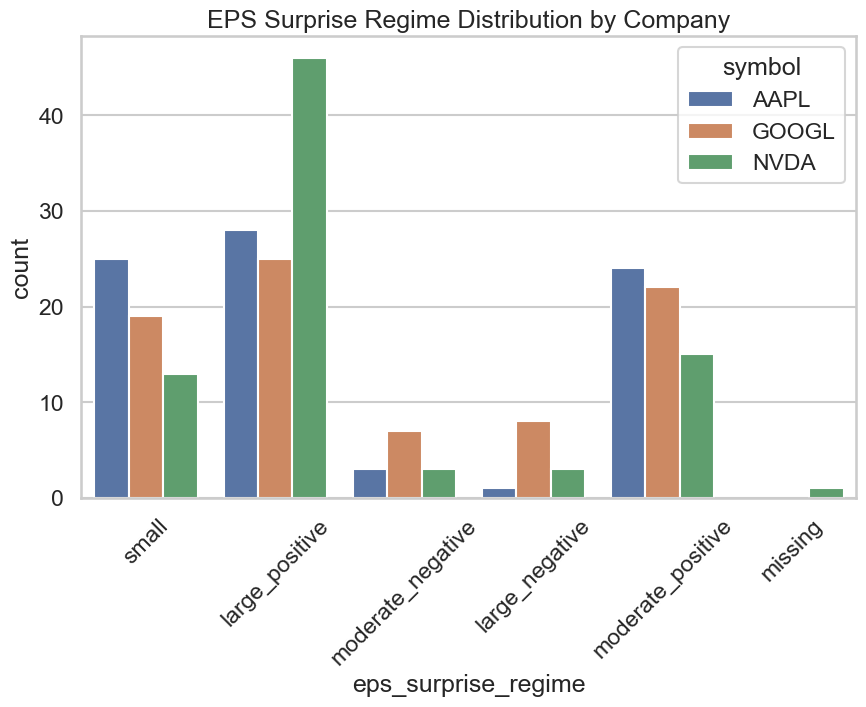

In [57]:
# Plot the bar chart
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.countplot(data=df, x="eps_surprise_regime", hue="symbol")
plt.title("EPS Surprise Regime Distribution by Company")
plt.xticks(rotation=45)
plt.show()

The chart compares how often Apple, Google, and NVIDIA fall into different EPS‑surprise categories. Apple and Google show fairly balanced distributions, with most of their surprises landing in the “small” or moderately positive range. NVIDIA stands out with a much larger number of large positive surprises, reflecting its more volatile and fast‑moving earnings profile. Negative surprises occur for all three companies but are far less common, and only a small number of observations fall into the “missing” category.

In [25]:
# Profitability Level Regimes (company‑relative)

def classify_profitability(margin):
    if margin > 0.25:
        return "high"
    elif margin > 0.10:
        return "medium"
    else:
        return "low"

df["profitability_regime"] = df["netMargin"].apply(classify_profitability)

df[[
    "symbol",
    "fiscalDateEnding",
    "profitability_regime",
]].head()


,symbol,fiscalDateEnding,profitability_regime
0,AAPL,2005-09-30,medium
1,AAPL,2005-12-31,low
2,AAPL,2006-03-31,low
3,AAPL,2006-06-30,medium
4,AAPL,2006-09-30,medium


Quarters with net margins above 25% are labeled “high,” capturing periods of exceptionally strong profitability. Margins between 10% and 25% fall into the “medium” category, representing healthy but not extraordinary performance. Anything below 10% is classified as “low,” indicating weaker or more volatile profitability. 

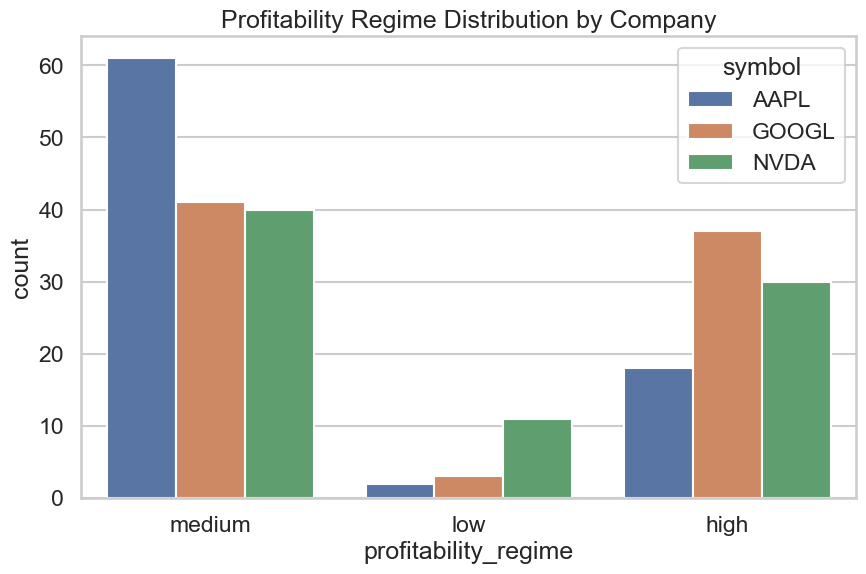

In [26]:
# Plot the bar chart
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="profitability_regime", hue="symbol")
plt.title("Profitability Regime Distribution by Company")
plt.show()

Apple shows a strong concentration in the medium‑profitability range, reflecting its steady and predictable margins. Google also has many medium‑profitability quarters but stands out with the highest count of high‑profitability periods among the three companies. NVIDIA displays a more mixed profile: it has more low‑profitability quarters than Apple or Google, especially from earlier years, but it also records a substantial number of high‑profitability periods as its margins expand in more recent years. Overall, the chart highlights Apple and Google’s stability and NVIDIA’s more variable but improving profitability trajectory.

In [27]:
# Margin Trend Regimes (QoQ change)

def classify_margin_trend(change):
    if pd.isna(change):
        return "missing"
    if change > 0.005:
        return "expansion"
    elif change < -0.005:
        return "contraction"
    else:
        return "stable"

df["margin_trend_regime"] = df["netMargin_change"].apply(classify_margin_trend)

df[[
    "symbol",
    "fiscalDateEnding",
    "margin_trend_regime",
]].head()


,symbol,fiscalDateEnding,margin_trend_regime
0,AAPL,2005-09-30,missing
1,AAPL,2005-12-31,contraction
2,AAPL,2006-03-31,stable
3,AAPL,2006-06-30,expansion
4,AAPL,2006-09-30,expansion


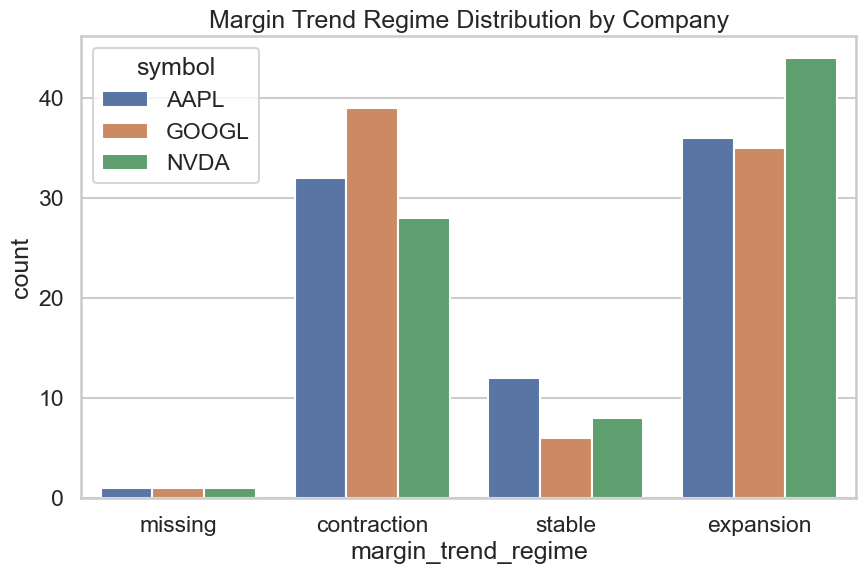

In [28]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="margin_trend_regime", hue="symbol")
plt.title("Margin Trend Regime Distribution by Company")
plt.show()

Apple shows the strongest tendency toward stable margins, reflecting its consistent operational performance. Google records the highest number of contraction periods, suggesting more frequent downward pressure on margins over time. NVIDIA stands out with the most expansion periods, consistent with its rapid growth phases and improving profitability in recent years. All three companies have very few missing observations, making the comparison clean and reliable. Overall, the chart highlights Apple’s steadiness, Google’s occasional margin tightening, and NVIDIA’s more dynamic margin trajectory.

In [48]:
# Revenue Growth Regimes (YoY)

def classify_revenue_growth(g):
    if pd.isna(g):
        return "missing"
    if g > 0.10:
        return "high_growth"
    elif g >= 0:
        return "moderate_growth"
    else:
        return "negative_growth"

df["revenue_growth_regime"] = df["revenue_yoy_growth"].apply(classify_revenue_growth)

df[[
    "symbol",
    "fiscalDateEnding",
    "revenue_growth_regime",
]].head()


,symbol,fiscalDateEnding,revenue_growth_regime
0,AAPL,2005-09-30,missing
1,AAPL,2005-12-31,missing
2,AAPL,2006-03-31,missing
3,AAPL,2006-06-30,missing
4,AAPL,2006-09-30,high_growth


Any value above 10% is labeled “high growth,” since double‑digit revenue expansion is widely viewed as a sign of strong business momentum. Growth between 0% and 10% is classified as “moderate,” capturing steady but not exceptional expansion. Negative values fall into the “negative growth” category, indicating a contraction in demand or a cyclical slowdown. 

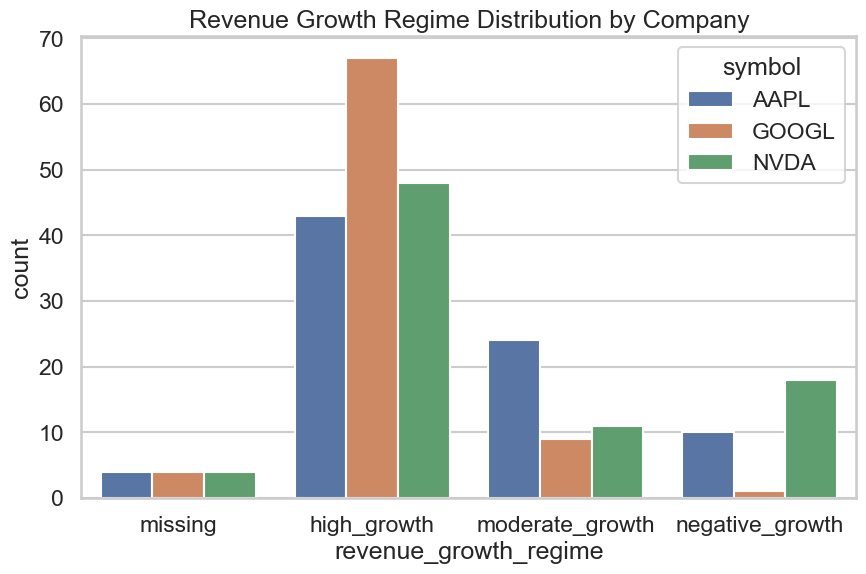

In [30]:
# Plot the bar chart
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="revenue_growth_regime", hue="symbol")
plt.title("Revenue Growth Regime Distribution by Company")
plt.show()

High growth is the most common category overall, especially for Google, which consistently shows strong top‑line expansion. Apple has a more balanced distribution, with many quarters in the moderate‑growth range, reflecting its mature but still steadily growing business. NVIDIA stands out with the highest number of negative‑growth periods, largely driven by its more cyclical demand patterns, but it also records a substantial number of high‑growth quarters during its rapid expansion phases. 

In [31]:
# Combined Financial Strength Regime

def combined_regime(row):
    strong = (
        row["profitability_regime"] == "high" and
        row["margin_trend_regime"] == "expansion" and
        row["eps_surprise_regime"] in ["large_positive", "moderate_positive"]
    )
    weak = (
        row["profitability_regime"] == "low" and
        row["margin_trend_regime"] == "contraction" and
        row["eps_surprise_regime"] in ["large_negative", "moderate_negative"]
    )
    if strong:
        return "strong_fundamentals"
    elif weak:
        return "weak_fundamentals"
    else:
        return "mixed"

df["financial_strength_regime"] = df.apply(combined_regime, axis=1)


df[[
    "symbol",
    "fiscalDateEnding",
    "financial_strength_regime"
]].head()


,symbol,fiscalDateEnding,financial_strength_regime
0,AAPL,2005-09-30,mixed
1,AAPL,2005-12-31,mixed
2,AAPL,2006-03-31,mixed
3,AAPL,2006-06-30,mixed
4,AAPL,2006-09-30,mixed


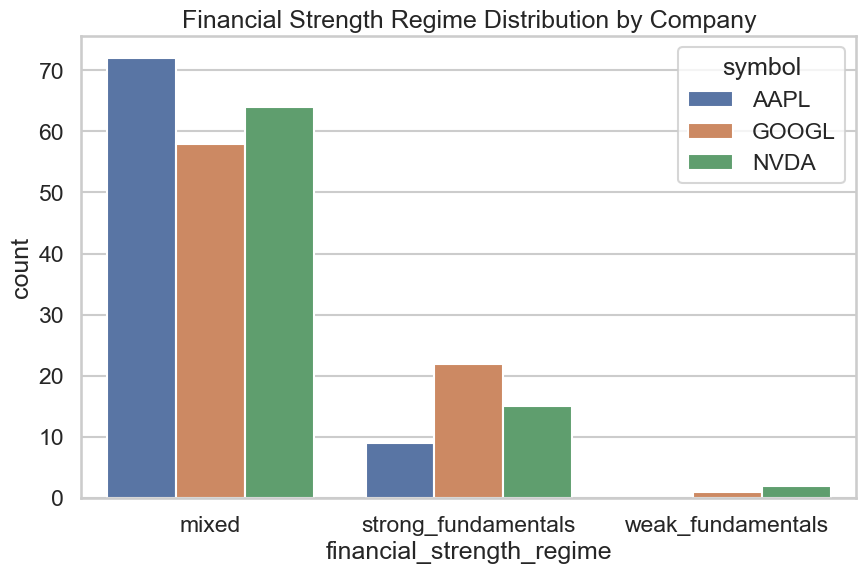

In [32]:
# Plot the bar chart
plt.figure(figsize=(10,6))
sns.countplot(data=df, x="financial_strength_regime", hue="symbol")
plt.title("Financial Strength Regime Distribution by Company")
plt.show()

All three companies spend most of their time in the mixed category, reflecting quarters where their profitability, margin trends, and earnings surprises do not all point in the same direction. Google and NVIDIA show a similar number of strong‑fundamentals quarters, slightly more than Apple, indicating periods where their margins, growth, and earnings surprises aligned positively. Weak‑fundamentals quarters are relatively rare overall, but Google records the most, followed by NVIDIA, while Apple has none.

Across all four regime systems—EPS surprise, profitability, margin trend, and revenue growth—a consistent story emerges about how the underlying fundamentals of Apple, Google, and NVIDIA behave over time. The individual regime distributions show that Apple tends to cluster in stable, medium‑profitability and moderate‑growth environments, while Google oscillates more between strong and weak fundamentals, and NVIDIA exhibits the widest swings, with both high‑growth, high‑profitability periods and occasional contractions. The financial‑strength regime, which combines all indicators, reinforces this: most quarters fall into the “mixed” category, but strong‑fundamentals periods align closely with NVIDIA’s expansion phases and Google’s high‑growth quarters, while weak‑fundamentals periods appear mainly when margins are contracting.

In [49]:
import pandas as pd
import numpy as np

# Load quarterly EPS and margin data
eps = pd.read_csv(r"D:/LSE Career Accelerator/Employer project/Adrian's financial metrics data/av_eps_quarterly.csv")
margins = pd.read_csv(r"D:/LSE Career Accelerator/Employer project/Adrian's financial metrics data/av_income_quarterly_margins.csv")

# Merge into a single event-level dataset
df_events = eps.merge(margins, on=["symbol", "fiscalDateEnding"], how="inner")

# Create event identifiers
df_events["fiscalDateEnding"] = df_events["fiscalDateEnding"].astype(str)
df_events["event_id"] = df_events["symbol"] + "_" + df_events["fiscalDateEnding"]
df_events["ticker"] = df_events["symbol"]

# Convert to datetime and sort
df_events["fiscalDateEnding"] = pd.to_datetime(df_events["fiscalDateEnding"])
df_events = df_events.sort_values(["symbol", "fiscalDateEnding"])

# Compute core financial metrics
df_events["revenue_growth"] = df_events.groupby("symbol")["totalRevenue"].pct_change()
df_events["margin_trend"] = df_events.groupby("symbol")["netMargin"].diff()
df_events["profitability"] = df_events["operatingMargin"]

# Apply regime classifiers
df_events["revenue_growth_regime"] = df_events["revenue_growth"].apply(classify_revenue_growth)
df_events["eps_surprise_regime"] = df_events["surprisePercentage"].apply(classify_surprise)
df_events["profitability_regime"] = df_events["profitability"].apply(classify_profitability)
df_events["margin_trend_regime"] = df_events["margin_trend"].apply(classify_margin_trend)

# Combined financial strength regime 
df_events["financial_strength_regime"] = df_events.apply(combined_regime, axis=1)

In [67]:
# View the dataset
df_events[[
    "symbol",
    "fiscalDateEnding",
    "eps_surprise_regime",
    "profitability_regime",
    "margin_trend_regime",
    "financial_strength_regime"
]].head()

,symbol,fiscalDateEnding,eps_surprise_regime,profitability_regime,margin_trend_regime,financial_strength_regime
80,AAPL,2005-09-30,small,medium,missing,mixed
79,AAPL,2005-12-31,small,medium,contraction,mixed
78,AAPL,2006-03-31,small,medium,stable,mixed
77,AAPL,2006-06-30,small,medium,expansion,mixed
76,AAPL,2006-09-30,small,medium,expansion,mixed


In [71]:
# Export the merged dataset to csv
df_events.to_csv(r"D:/LSE Career Accelerator/Employer project/Adrian's financial metrics data/full_event_regimes.csv", index=False)